### PHASE 1

In [ ]:
!pip install pandas matplotlib seaborn textblob

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [3]:
data = {
    "Review": [
        "The hotel staff was extremely friendly and helpful",
        "Check-in process was very slow and frustrating",
        "Amazing food and beautiful ambience",
        "Room cleanliness was disappointing",
        "Excellent customer service and quick response",
        "The location was perfect for travel",
        "Poor WiFi connection during the stay",
        "Loved the luxury experience and hospitality"
    ]
}

df = pd.DataFrame(data)

df

,Review
0,The hotel staff was extremely friendly and hel...
1,Check-in process was very slow and frustrating
2,Amazing food and beautiful ambience
3,Room cleanliness was disappointing
4,Excellent customer service and quick response
5,The location was perfect for travel
6,Poor WiFi connection during the stay
7,Loved the luxury experience and hospitality


In [4]:
def get_sentiment(review):
    analysis = TextBlob(review)

    if analysis.sentiment.polarity > 0:
        return "Positive"
    elif analysis.sentiment.polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Review"].apply(get_sentiment)

df

,Review,Sentiment
0,The hotel staff was extremely friendly and hel...,Positive
1,Check-in process was very slow and frustrating,Negative
2,Amazing food and beautiful ambience,Positive
3,Room cleanliness was disappointing,Negative
4,Excellent customer service and quick response,Positive
5,The location was perfect for travel,Positive
6,Poor WiFi connection during the stay,Negative
7,Loved the luxury experience and hospitality,Positive


In [5]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    5
Negative    3
Name: count, dtype: int64


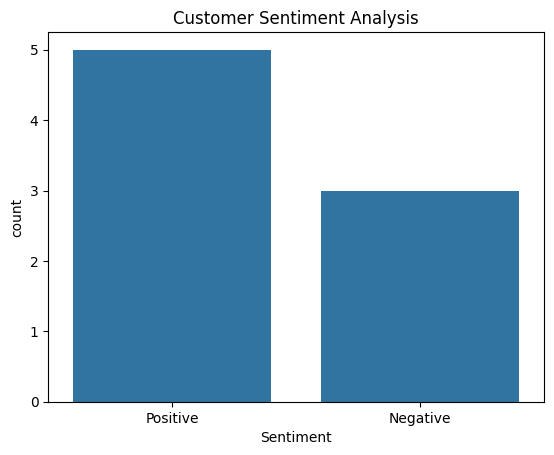

In [6]:
sns.countplot(x="Sentiment", data=df)

plt.title("Customer Sentiment Analysis")
plt.show()

### PHASE 2

In [9]:
def categorize_review(review):
    review = review.lower()

    if "staff" in review or "service" in review or "hospitality" in review:
        return "Staff Service"

    elif "food" in review or "restaurant" in review:
        return "Food & Dining"

    elif "clean" in review or "cleanliness" in review or "room" in review:
        return "Room Cleanliness"

    elif "check-in" in review:
        return "Check-in Experience"

    elif "wifi" in review or "internet" in review:
        return "WiFi"

    elif "location" in review:
        return "Location"

    else:
        return "Other"

In [10]:
df["Category"] = df["Review"].apply(categorize_review)

df

,Review,Sentiment,Category
0,The hotel staff was extremely friendly and hel...,Positive,Staff Service
1,Check-in process was very slow and frustrating,Negative,Check-in Experience
2,Amazing food and beautiful ambience,Positive,Food & Dining
3,Room cleanliness was disappointing,Negative,Room Cleanliness
4,Excellent customer service and quick response,Positive,Staff Service
5,The location was perfect for travel,Positive,Location
6,Poor WiFi connection during the stay,Negative,WiFi
7,Loved the luxury experience and hospitality,Positive,Staff Service


In [11]:
category_counts = df["Category"].value_counts()

print(category_counts)

Category
Staff Service          3
Check-in Experience    1
Food & Dining          1
Room Cleanliness       1
Location               1
WiFi                   1
Name: count, dtype: int64


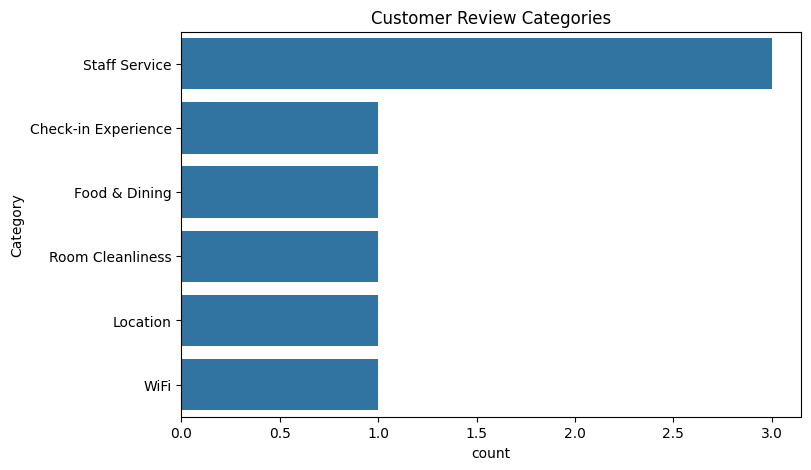

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(y="Category", data=df, order=df["Category"].value_counts().index)

plt.title("Customer Review Categories")
plt.show()

### PHASE 3

In [17]:
brand_identity = {
    "Staff Service": "Premium Hospitality",
    "Food & Dining": "Luxury Dining Experience",
    "Room Cleanliness": "Comfort & Cleanliness",
    "Check-in Experience": "Fast & Seamless Service",
    "WiFi": "Modern Convenience",
    "Location": "Travel Accessibility"
}

brand_identity

{'Staff Service': 'Premium Hospitality',
 'Food & Dining': 'Luxury Dining Experience',
 'Room Cleanliness': 'Comfort & Cleanliness',
 'Check-in Experience': 'Fast & Seamless Service',
 'WiFi': 'Modern Convenience',
 'Location': 'Travel Accessibility'}

In [18]:
def sentiment_score(sentiment):
    if sentiment == "Positive":
        return 1
    elif sentiment == "Negative":
        return -1
    else:
        return 0

df["Sentiment Score"] = df["Sentiment"].apply(sentiment_score)

category_sentiment = df.groupby("Category")["Sentiment Score"].mean()

category_sentiment

,Sentiment Score
Category,
Check-in Experience,-1.0
Food & Dining,1.0
Location,1.0
Room Cleanliness,-1.0
Staff Service,1.0
WiFi,-1.0


In [19]:
alignment_results = []

for category, score in category_sentiment.items():

    if score >= 0:
        status = "Aligned"
    else:
        status = "Misaligned"

    alignment_results.append({
        "Category": category,
        "Brand Promise": brand_identity.get(category, "Unknown"),
        "Sentiment Score": round(score, 2),
        "Alignment Status": status
    })

alignment_df = pd.DataFrame(alignment_results)

alignment_df

,Category,Brand Promise,Sentiment Score,Alignment Status
0,Check-in Experience,Fast & Seamless Service,-1.0,Misaligned
1,Food & Dining,Luxury Dining Experience,1.0,Aligned
2,Location,Travel Accessibility,1.0,Aligned
3,Room Cleanliness,Comfort & Cleanliness,-1.0,Misaligned
4,Staff Service,Premium Hospitality,1.0,Aligned
5,WiFi,Modern Convenience,-1.0,Misaligned


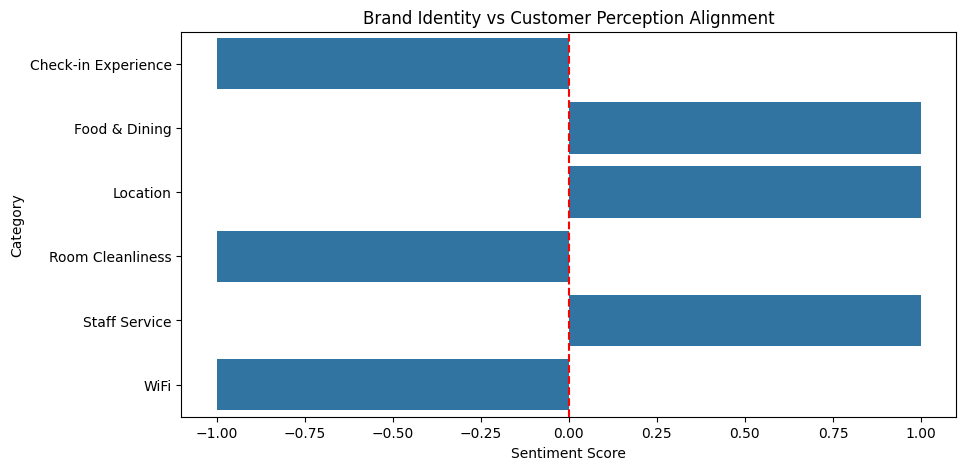

In [20]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Sentiment Score",
    y="Category",
    data=alignment_df
)

plt.axvline(0, color='red', linestyle='--')

plt.title("Brand Identity vs Customer Perception Alignment")

plt.show()

### PHASE 4

In [22]:
def generate_recommendation(category):

    recommendations = {
        "Staff Service": "Improve staff training and personalized customer interaction.",

        "Food & Dining": "Enhance menu quality and dining experience consistency.",

        "Room Cleanliness": "Strengthen housekeeping quality checks and cleanliness standards.",

        "Check-in Experience": "Reduce waiting time through digital check-in systems.",

        "WiFi": "Upgrade internet infrastructure for seamless connectivity.",

        "Location": "Provide better transport guidance and accessibility support."
    }

    return recommendations.get(category, "No recommendation available")

In [23]:
alignment_df["Recommendation"] = alignment_df.apply(
    lambda row: generate_recommendation(row["Category"])
    if row["Alignment Status"] == "Misaligned"
    else "Maintain current service quality",
    axis=1
)

alignment_df

,Category,Brand Promise,Sentiment Score,Alignment Status,Recommendation
0,Check-in Experience,Fast & Seamless Service,-1.0,Misaligned,Reduce waiting time through digital check-in s...
1,Food & Dining,Luxury Dining Experience,1.0,Aligned,Maintain current service quality
2,Location,Travel Accessibility,1.0,Aligned,Maintain current service quality
3,Room Cleanliness,Comfort & Cleanliness,-1.0,Misaligned,Strengthen housekeeping quality checks and cle...
4,Staff Service,Premium Hospitality,1.0,Aligned,Maintain current service quality
5,WiFi,Modern Convenience,-1.0,Misaligned,Upgrade internet infrastructure for seamless c...


In [24]:
misaligned = alignment_df[
    alignment_df["Alignment Status"] == "Misaligned"
]

print("Key Misaligned Areas:")
print(misaligned[["Category", "Recommendation"]])

Key Misaligned Areas:
              Category                                     Recommendation
0  Check-in Experience  Reduce waiting time through digital check-in s...
3     Room Cleanliness  Strengthen housekeeping quality checks and cle...
5                 WiFi  Upgrade internet infrastructure for seamless c...
